
              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0-post0.dev0
 Built: Dec  9 2024 17:34:57

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


Aug 01 23:59:44 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.001 ms.

Aug 01 23:59:44 Install [Info]: 
    loaded module adex_2expnms_gap_rec_module

Aug 01 23:59:44 Install [Info]: 
    loaded module adex_2expnms_rec_module

Aug 01 23:59:44 NodeManager::prepare_nodes [Info]: 
    Preparing 4 nodes for simulation.

Aug 01 23:59:44 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 4
    Simulation time (ms): 2000
    Number of OpenMP threads: 1
    Not using MPI

Aug 01 23:59:45 SimulationManager::run [Info]: 
    Simulation finished.

     COMPREHENSIVE ADEX MODEL ANALYSIS (TOUBOUL & BRETTE

/tmp/ipykernel_1502/1780674924.py:260: RuntimeWarning:invalid value encountered in sqrt


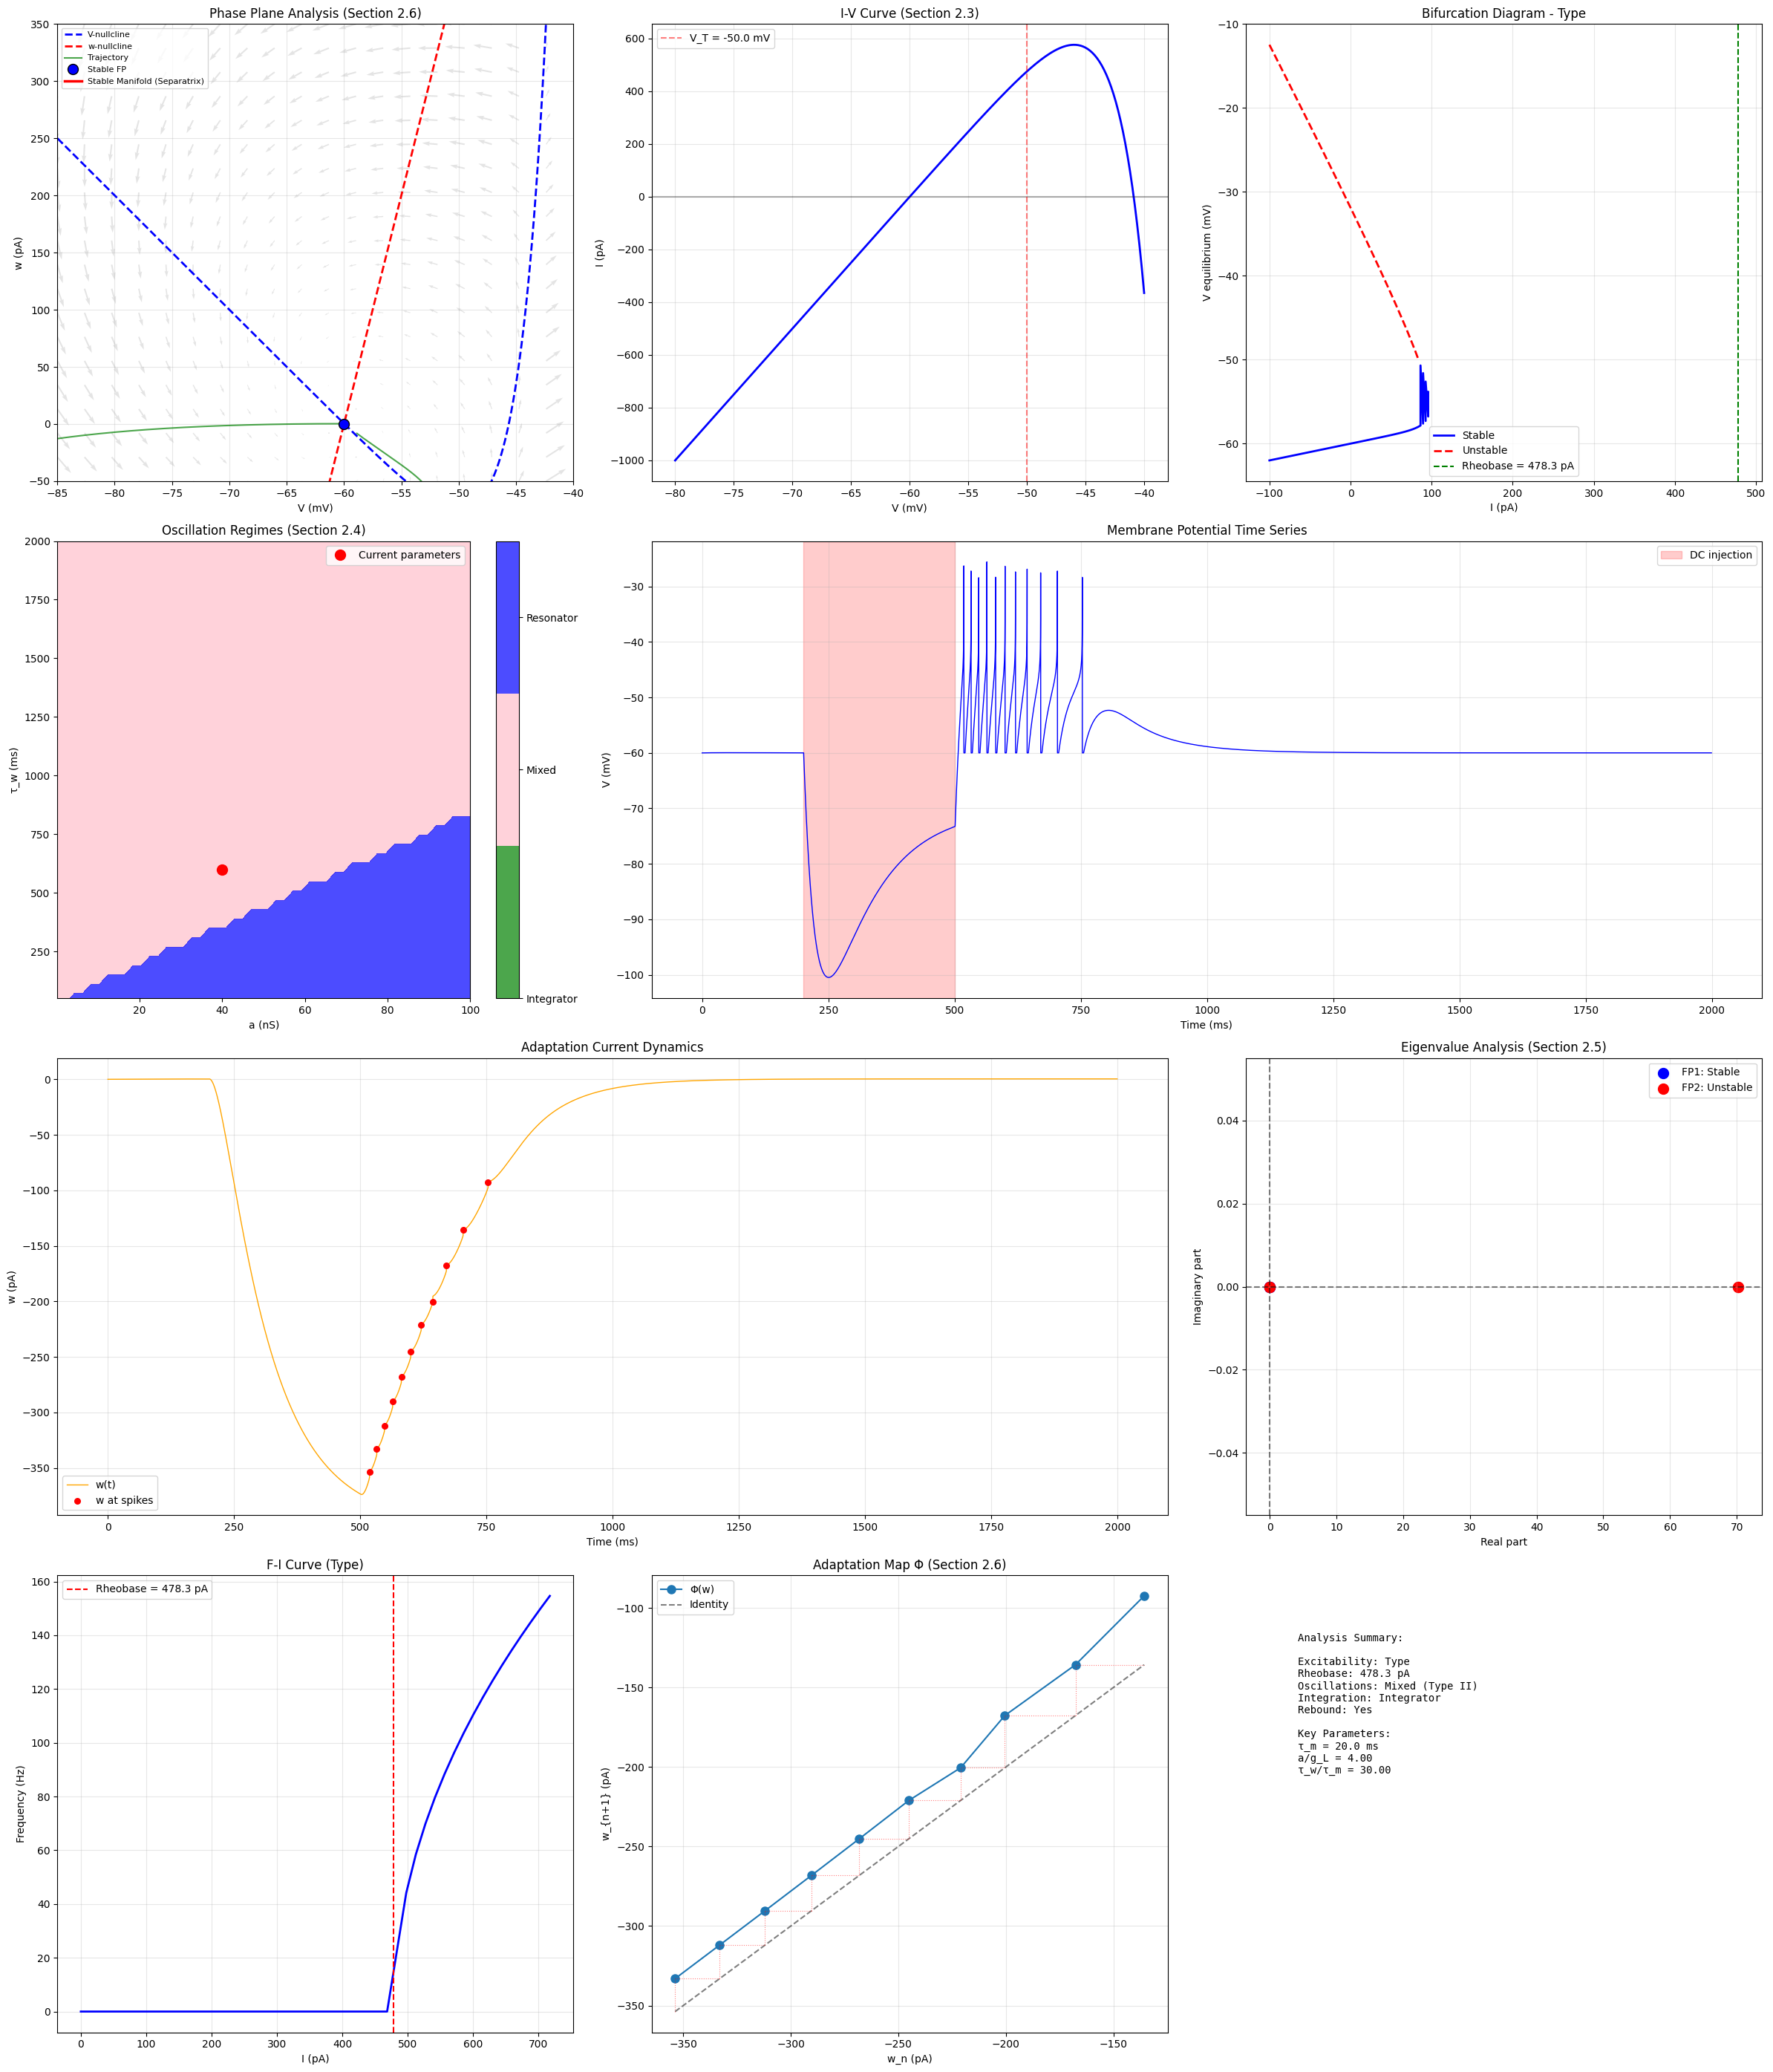

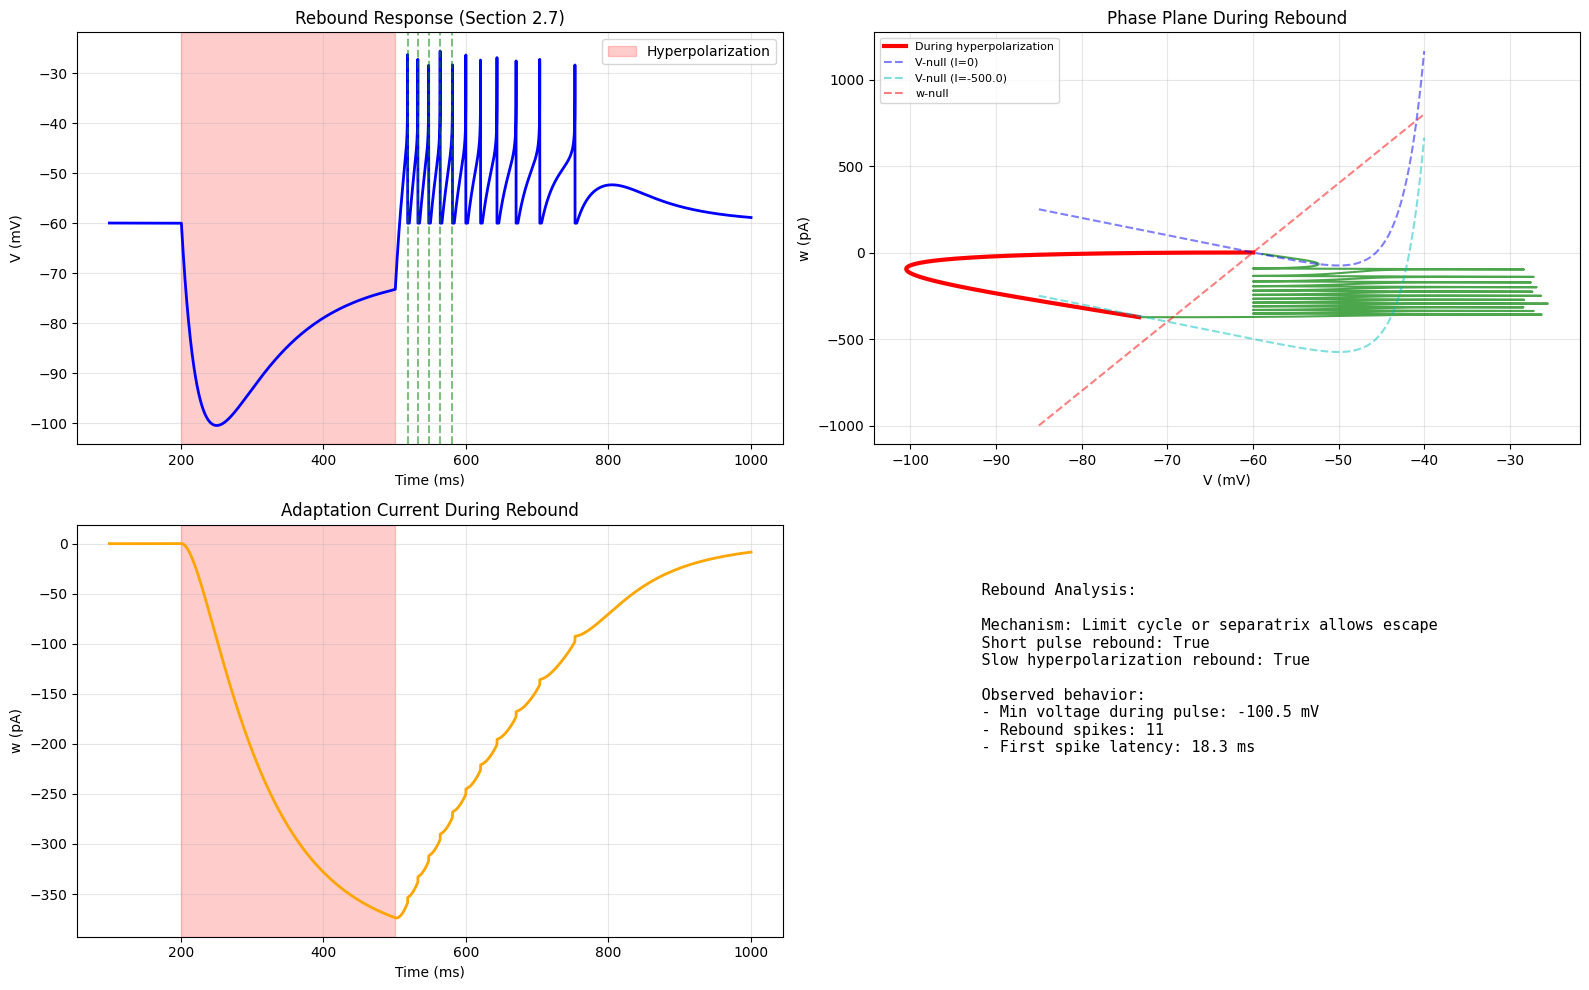


Analysis complete. All sections from Touboul & Brette (2008) implemented.


In [2]:
import nest
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd
import seaborn as sns
from scipy.optimize import fsolve, brentq
from scipy.special import lambertw
import numpy.linalg as LA
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection

# --- Simulation Parameters ---
amplitude_dc = -500.0       # pA
start_dc = 200.0           # ms
end_dc = 500.0             # ms
simtime = 2000.0           # ms

params_dict = {
    "C_m": 200.0,             # pF
    "g_L": 10.0,              # nS
    "E_L": -60.0,             # mV 
    "E_AMPA": 0,              # mV 
    "E_GABAA": -80,           # mV
    "E_GABAB": -90,           # mV
    "E_NMDA": 0,              # mV
    "Delta_T": 2.5,           # mV
    "V_th": -50.0,            # mV
    "V_reset": -60.0,         # mV
    "V_peak": 0.0,            # mV
    "t_ref": 2.5,             # ms
    "tau_w": 600.0,           # ms
    "a_param": 40.0,          # nS
    "b_param": 5.0,           # pA
    "tau_decay_AMPA": 5,      # ms
    "tau_rise_AMPA": 0.4,     # ms
    "tau_decay_GABAA": 20,    # ms
    "tau_rise_GABAA": 0.4,    # ms
    "tau_decay_GABAB": 200,   # ms
    "tau_rise_GABAB": 5,      # ms
    "tau_decay_NMDA": 150,    # ms
    "tau_rise_NMDA": 2,       # ms
    "I_e": 0                  # pA
}

# --- NEST Simulation Setup ---
nest.ResetKernel()
nest.SetKernelStatus({"resolution": 0.001})
nest.Install("adex_2expnms_gap_rec_module")
nest.Install("adex_2expnms_rec_module")

neuron = nest.Create("adex_2expnms_rec_neuron")
neuron.set(params_dict)

dc = False
pos_dc = False

if amplitude_dc != 0:
    dc = True
    if (amplitude_dc > 0):
        pos_dc = True
    dc_current = nest.Create("dc_generator", params={"start": start_dc, "stop": end_dc, "amplitude": amplitude_dc})
    nest.Connect(dc_current, neuron)

multimeter = nest.Create("multimeter", params={"record_from": ["V_m", "w" , "I_syn_AMPA", "I_syn_NMDA", "I_syn_GABAA", "I_syn_GABAB"], "interval": 0.004})
spikerecorder = nest.Create("spike_recorder")
nest.Connect(multimeter, neuron)
nest.Connect(neuron, spikerecorder)

nest.Simulate(simtime)

# --- Data Extraction ---
data = multimeter.get()
Vms = data["events"]["V_m"]
ws = data["events"]["w"]
I_AMPA = data["events"]["I_syn_AMPA"]
I_NMDA = data["events"]["I_syn_NMDA"]
I_GABAA = data["events"]["I_syn_GABAA"]
I_GABAB = data["events"]["I_syn_GABAB"]
times = data["events"]["times"]
spike_times = spikerecorder.get("events")["times"]

# --- Parameter Extraction for Analysis ---
params = nest.GetStatus(neuron)[0]
g_L = params["g_L"]
E_L = params["E_L"]
V_T = params["V_th"]
Delta_T = params["Delta_T"]
a = params["a_param"]
C_m = params["C_m"]
tau_w = params["tau_w"]
b = params["b_param"]
V_r = params["V_reset"]

# =====================================
# SECTION 2.1: RESCALING
# =====================================
def rescale_parameters(params):
    """Section 2.1: Rescale parameters to dimensionless units"""
    g_L = params["g_L"]
    C_m = params["C_m"]
    a = params["a_param"]
    b = params["b_param"]
    tau_w = params["tau_w"]
    E_L = params["E_L"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    V_r = params["V_reset"]
    
    tau_m = C_m / g_L
    
    # Rescaled parameters (Eq. 5)
    tau_w_bar = tau_w / tau_m
    a_bar = a / g_L
    b_bar = b / (g_L * Delta_T)
    V_r_bar = (V_r - V_T) / Delta_T
    
    # For rescaling current
    def I_bar(I):
        return I / (g_L * Delta_T) + (1 + a/g_L) * (E_L - V_T) / Delta_T
    
    return {
        'tau_w_bar': tau_w_bar,
        'a_bar': a_bar,
        'b_bar': b_bar,
        'V_r_bar': V_r_bar,
        'tau_m': tau_m,
        'I_bar_func': I_bar
    }

# =====================================
# SECTION 2.2: EXCITABILITY
# =====================================
def determine_excitability_and_rheobase(p):
    """Section 2.2.1 & 2.2.2: Determine excitability type and rheobase current"""
    g_L, C_m, a = p["g_L"], p["C_m"], p["a_param"]
    E_L, V_T, Delta_T = p["E_L"], p["V_th"], p["Delta_T"]
    tau_w = p["tau_w"]
    
    tau_m = C_m / g_L
    
    # Critical ratio determining excitability type
    critical_ratio = (a / g_L) / (tau_m / tau_w)
    
    if (a / g_L) < (tau_m / tau_w):
        excitability_type = "Type I (Saddle-Node Bifurcation)"
        # Eq. 7: Rheobase for Type I
        rheobase = (g_L + a) * (V_T - E_L - Delta_T + Delta_T * np.log(1 + a / g_L))
    else:
        excitability_type = "Type II (Andronov-Hopf Bifurcation)"
        # Eq. 8: Rheobase for Type II
        rheobase = ((g_L + a) * (V_T - E_L - Delta_T + Delta_T * np.log(1 + tau_m / tau_w)) 
                   + Delta_T * g_L * (a/g_L - tau_m/tau_w))
    
    # Calculate voltage thresholds (Section 2.2.3 & 2.2.4)
    if (a / g_L) < (tau_m / tau_w):
        V_threshold_slow = V_T + Delta_T * np.log(1 + a/g_L)
    else:
        V_threshold_slow = V_T + Delta_T * np.log(1 + tau_m/tau_w)
    
    return {
        'type': excitability_type,
        'rheobase': rheobase,
        'critical_ratio': critical_ratio,
        'V_threshold_slow': V_threshold_slow
    }

# Fixed point analysis using Lambert W function (Eq. 6)
def find_fixed_points_lambert(I_inj, params):
    """Find fixed points using Lambert W function"""
    g_L = params["g_L"]
    a = params["a_param"]
    E_L = params["E_L"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    
    # Calculate the argument for Lambert W
    arg = -(1/(Delta_T * (g_L + a))) * np.exp((I_inj/(1 + a/g_L) + E_L - V_T)/Delta_T)
    
    fixed_points = []
    
    # Check if argument is in valid range
    if arg >= -1/np.e and arg < 0:
        # V- using W0 (principal branch)
        W0_val = np.real(lambertw(arg, k=0))
        V_minus = E_L + I_inj/(g_L + a) - Delta_T * W0_val
        fixed_points.append(V_minus)
        
        # V+ using W-1 branch
        W_minus1_val = np.real(lambertw(arg, k=-1))
        V_plus = E_L + I_inj/(g_L + a) - Delta_T * W_minus1_val
        if V_plus != V_minus:  # Avoid duplicates
            fixed_points.append(V_plus)
    
    return sorted(fixed_points)

# =====================================
# SECTION 2.3: I-V CURVE
# =====================================
def IV_curve(V, params):
    """Section 2.3: Calculate I-V relationship"""
    g_L = params["g_L"]
    a = params["a_param"]
    E_L = params["E_L"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    
    return (a + g_L) * (V - E_L) - g_L * Delta_T * np.exp((V - V_T) / Delta_T)

# =====================================
# SECTION 2.4: OSCILLATIONS
# =====================================
def analyze_oscillations(params, I_inj=0):
    """Section 2.4: Determine oscillation conditions and frequency"""
    g_L = params["g_L"]
    a = params["a_param"]
    C_m = params["C_m"]
    tau_w = params["tau_w"]
    E_L = params["E_L"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    
    tau_m = C_m / g_L
    
    # Check condition (9)
    condition_9 = (a/g_L) < (tau_m/(4*tau_w)) * (1 - tau_w/tau_m)**2
    
    # Determine oscillation regime
    oscillation_info = {
        'condition_9': condition_9,
        'tau_m': tau_m,
        'tau_w': tau_w,
        'a_over_gL': a/g_L,
        'tau_m_over_tau_w': tau_m/tau_w
    }
    
    # Classify oscillation behavior
    if (a/g_L) < (tau_m/tau_w):  # Type I
        if not condition_9:
            oscillation_info['regime'] = 'Resonator (Type I)'
            oscillation_info['description'] = 'Oscillates for I < I+'
        elif tau_m > tau_w:
            oscillation_info['regime'] = 'Integrator (Type I)'
            oscillation_info['description'] = 'Never oscillates'
        else:
            oscillation_info['regime'] = 'Mixed (Type I)'
            oscillation_info['description'] = 'Oscillates for I- < I < I+'
    else:  # Type II
        if not condition_9:
            oscillation_info['regime'] = 'Resonator (Type II)'
            oscillation_info['description'] = 'Always oscillates'
        else:
            oscillation_info['regime'] = 'Mixed (Type II)'
            oscillation_info['description'] = 'Oscillates for I > I-'
    
    # Calculate oscillation frequency if applicable (Eq. 10)
    fixed_points = find_fixed_points_lambert(I_inj, params)
    if fixed_points:
        V_minus = min(fixed_points)
        omega = np.sqrt((2*a)/(g_L*tau_w) - (2/tau_m) * np.exp((V_minus - V_T)/Delta_T) 
                       - (1 + tau_m/tau_w)**2)
        if omega > 0:
            oscillation_info['frequency'] = omega / (2 * np.pi)
        else:
            oscillation_info['frequency'] = 0
    
    return oscillation_info

# =====================================
# SECTION 2.5: INPUT INTEGRATION
# =====================================
def analyze_input_integration(params, V_eq):
    """Section 2.5: Analyze input integration properties"""
    g_L = params["g_L"]
    a = params["a_param"]
    C_m = params["C_m"]
    tau_w = params["tau_w"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    
    tau_m = C_m / g_L
    
    # Calculate eigenvalues at equilibrium
    jacobian, eigenvalues = calculate_jacobian_and_eigenvalues(V_eq, params)
    
    integration_info = {}
    
    # Check if eigenvalues are complex (resonator) or real (integrator)
    if np.any(np.iscomplex(eigenvalues)):
        integration_info['mode'] = 'Resonator'
        integration_info['eigenvalues'] = eigenvalues
        # Effective time constant (Eq. 11)
        integration_info['tau_eff'] = 2 * tau_m * tau_w / (tau_m + tau_w)
    else:
        integration_info['mode'] = 'Integrator'
        integration_info['eigenvalues'] = eigenvalues
        # Two time constants from real eigenvalues
        integration_info['tau_1'] = -1 / np.real(eigenvalues[0])
        integration_info['tau_2'] = -1 / np.real(eigenvalues[1])
    
    # Check for adaptation overshoot (Section 2.5.2)
    if integration_info['mode'] == 'Integrator' and tau_m < tau_w:
        # Check if slower eigenvalue creates negative component
        if np.real(eigenvalues[0]) > np.real(eigenvalues[1]):
            integration_info['adaptation_type'] = 'Overshoot possible'
        else:
            integration_info['adaptation_type'] = 'Monotonic'
    else:
        integration_info['adaptation_type'] = 'Oscillatory' if integration_info['mode'] == 'Resonator' else 'Monotonic'
    
    return integration_info

# =====================================
# SECTION 2.6: ATTRACTION BASIN
# =====================================
def analyze_limit_cycle(params, I_inj):
    """Section 2.6.1: Check for limit cycle existence"""
    g_L = params["g_L"]
    a = params["a_param"]
    C_m = params["C_m"]
    tau_w = params["tau_w"]
    V_T = params["V_th"]
    E_L = params["E_L"]
    Delta_T = params["Delta_T"]
    
    tau_m = C_m / g_L
    
    # Check if Type II
    if (a/g_L) > (tau_m/tau_w):
        # Calculate I_cycle (Eq. 12)
        C = g_L * tau_m / tau_w
        I_BT = (g_L + C/tau_w) * (V_T - E_L - Delta_T + Delta_T * np.log(1 + C/(g_L*tau_w)))
        
        if a > C/tau_w:
            I_cycle = I_BT - (12/25) * (Delta_T * tau_w**2) / (C * (tau_m + tau_w)) * (a - C/tau_w)**2
        else:
            I_cycle = I_BT
        
        return {
            'has_limit_cycle': I_inj > I_cycle,
            'I_cycle': I_cycle,
            'type': 'Repulsive limit cycle' if I_inj > I_cycle else 'No limit cycle'
        }
    else:
        return {
            'has_limit_cycle': False,
            'type': 'No limit cycle (Type I)'
        }

def plot_stable_manifold_advanced(ax, equilibria, params, I_inj=0, n_steps=5000, dt=0.1, plot_xlim=[-90, -40], plot_ylim=[-100, 100]):
    """Section 2.6.2: Enhanced separatrix plotting"""
    C_m, g_L, E_L, V_T, Delta_T, a, tau_w = (params["C_m"], params["g_L"], params["E_L"], 
                                             params["V_th"], params["Delta_T"], params["a_param"], params["tau_w"])
    
    def dVdt(V, w, I):
        return (1/C_m) * (-g_L * (V - E_L) + g_L * Delta_T * np.exp((V - V_T) / Delta_T) - w + I)
    
    def dWdt(V, w):
        return (1/tau_w) * (a * (V - E_L) - w)

    saddle_point_v = None
    stable_eigenvector = None

    for v_eq in equilibria:
        jacobian, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq, params)
        # Check for saddle point (one positive, one negative eigenvalue)
        if np.any(np.real(eigenvalues) > 0) and np.any(np.real(eigenvalues) < 0):
            saddle_point_v = v_eq
            _, eigenvectors = LA.eig(jacobian)
            stable_idx = np.argmin(np.real(eigenvalues))
            stable_eigenvector = np.real(eigenvectors[:, stable_idx])
            break
            
    if saddle_point_v is None:
        return

    w_saddle = a * (saddle_point_v - E_L)
    saddle_point = np.array([saddle_point_v, w_saddle])
    
    # Plot both branches of stable manifold
    for sign in [-1, 1]:
        path = []
        v, w = saddle_point + sign * 1e-4 * stable_eigenvector
        
        for _ in range(n_steps):
            path.append([v, w])
            v_prime = dVdt(v, w, I_inj)
            w_prime = dWdt(v, w)
            v -= v_prime * dt
            w -= w_prime * dt
            if not (plot_xlim[0] < v < plot_xlim[1] and plot_ylim[0] < w < plot_ylim[1]):
                break
        
        if path:
            path = np.array(path)
            ax.plot(path[:, 0], path[:, 1], color='red', linewidth=2.5, linestyle='-', 
                    label='Stable Manifold (Separatrix)' if sign == -1 else "")

# =====================================
# SECTION 2.7: REBOUND
# =====================================
def analyze_rebound_properties(params):
    """Section 2.7: Analyze rebound spiking properties"""
    g_L = params["g_L"]
    a = params["a_param"]
    C_m = params["C_m"]
    tau_w = params["tau_w"]
    
    tau_m = C_m / g_L
    
    # Check condition (9)
    condition_9 = (a/g_L) < (tau_m/(4*tau_w)) * (1 - tau_w/tau_m)**2
    
    rebound_info = {}
    
    # Determine rebound possibilities based on excitability type
    if (a/g_L) < (tau_m/tau_w):  # Type I
        if tau_m < tau_w or not condition_9:
            rebound_info['short_pulse_rebound'] = True
            rebound_info['slow_hyperpolarization_rebound'] = True
            rebound_info['mechanism'] = 'Separatrix crosses w-nullcline'
        else:
            rebound_info['short_pulse_rebound'] = False
            rebound_info['slow_hyperpolarization_rebound'] = False
            rebound_info['mechanism'] = 'No rebound (integrator regime)'
    else:  # Type II
        rebound_info['short_pulse_rebound'] = True
        rebound_info['slow_hyperpolarization_rebound'] = True
        rebound_info['mechanism'] = 'Limit cycle or separatrix allows escape'
    
    return rebound_info

# =====================================
# SECTION 2.8: AFTER-POTENTIAL
# =====================================
def analyze_after_potential(params, V_reset, w_after_spike):
    """Section 2.8: Analyze after-potential characteristics"""
    g_L = params["g_L"]
    E_L = params["E_L"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    tau_w = params["tau_w"]
    b = params["b_param"]
    
    # V-nullcline at reset
    V_nullcline_at_reset = -g_L * (V_reset - E_L) + g_L * Delta_T * np.exp((V_reset - V_T) / Delta_T)
    
    after_potential_info = {}
    
    # Determine after-potential type
    if w_after_spike > V_nullcline_at_reset:
        after_potential_info['type'] = 'Broad'
        after_potential_info['description'] = 'V decreases then increases'
    else:
        after_potential_info['type'] = 'Sharp'
        after_potential_info['description'] = 'V increases monotonically'
    
    # Analyze contributing factors
    if b > 50:  # Large spike-triggered adaptation
        after_potential_info['b_contribution'] = 'Large b promotes broad after-potential'
    else:
        after_potential_info['b_contribution'] = 'Small b promotes sharp after-potential'
    
    if tau_w > 500:  # Slow adaptation
        after_potential_info['tau_w_contribution'] = 'Large tau_w promotes broad after-potential'
    else:
        after_potential_info['tau_w_contribution'] = 'Small tau_w promotes sharp after-potential'
    
    return after_potential_info

# =====================================
# ENHANCED HELPER FUNCTIONS
# =====================================
def calculate_jacobian_and_eigenvalues(V_eq, params):
    """Calculate Jacobian matrix and eigenvalues at equilibrium point"""
    g_L = params["g_L"]
    C_m = params["C_m"]
    a = params["a_param"]
    tau_w = params["tau_w"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    
    dF_dV = (1 / C_m) * (-g_L + g_L * np.exp((V_eq - V_T) / Delta_T))
    dF_dw = -1 / C_m
    dG_dV = a / tau_w
    dG_dw = -1 / tau_w
    
    jacobian_matrix = np.array([
        [dF_dV, dF_dw],
        [dG_dV, dG_dw]
    ])
    
    eigenvalues = LA.eigvals(jacobian_matrix)
    return jacobian_matrix, eigenvalues

def find_equilibrium_function(V, I_inj, params):
    """Function for finding equilibrium points"""
    g_L = params["g_L"]
    E_L = params["E_L"]
    V_T = params["V_th"]
    Delta_T = params["Delta_T"]
    a = params["a_param"]
    
    return (a + g_L) * (V - E_L) - g_L * Delta_T * np.exp((V - V_T) / Delta_T) - I_inj

# =====================================
# COMPREHENSIVE ANALYSIS REPORT
# =====================================
print("\n" + "="*70)
print("     COMPREHENSIVE ADEX MODEL ANALYSIS (TOUBOUL & BRETTE 2008)")
print("="*70 + "\n")

# Section 2.1: Rescaling
print("--- SECTION 2.1: RESCALING ---")
rescaled = rescale_parameters(params)
print(f"  Membrane time constant (τ_m): {rescaled['tau_m']:.2f} ms")
print(f"  Rescaled parameters:")
print(f"    τ̄_w = τ_w/τ_m = {rescaled['tau_w_bar']:.3f}")
print(f"    ā = a/g_L = {rescaled['a_bar']:.3f}")
print(f"    b̄ = b/(g_L·ΔT) = {rescaled['b_bar']:.3f}")
print(f"    V̄_r = (V_r - V_T)/ΔT = {rescaled['V_r_bar']:.3f}")
print(f"  Dimensionless current transformation: Ī = I/(g_L·ΔT) + (1+a/g_L)(E_L-V_T)/ΔT")

# Section 2.2: Excitability
print("\n--- SECTION 2.2: EXCITABILITY ANALYSIS ---")
excitability_analysis = determine_excitability_and_rheobase(params)
print(f"  Excitability type: {excitability_analysis['type']}")
print(f"  Critical ratio (a/g_L)/(τ_m/τ_w): {excitability_analysis['critical_ratio']:.3f}")
print(f"  Theoretical rheobase current: {excitability_analysis['rheobase']:.2f} pA")
print(f"  Voltage threshold (slow inputs): {excitability_analysis['V_threshold_slow']:.2f} mV")

# Find fixed points using Lambert W
print("\n  Fixed points at I=0 (using Lambert W function):")
fp_lambert = find_fixed_points_lambert(0, params)
for i, v_eq in enumerate(fp_lambert):
    w_eq = a * (v_eq - E_L)
    _, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq, params)
    stability = "Stable" if np.all(np.real(eigenvalues) < 0) else "Saddle"
    print(f"    V_{'-' if i==0 else '+'} = {v_eq:.2f} mV, w = {w_eq:.2f} pA [{stability}]")

# Section 2.3: I-V Curve
print("\n--- SECTION 2.3: I-V CURVE ANALYSIS ---")
V_test = np.linspace(-80, -40, 100)
I_values = [IV_curve(v, params) for v in V_test]
print(f"  I-V curve: I(V) = (a+g_L)(V-E_L) - g_L·ΔT·exp((V-V_T)/ΔT)")
print(f"  Far from threshold slope: {a + g_L:.2f} nS (leak + adaptation conductance)")

# Section 2.4: Oscillations
print("\n--- SECTION 2.4: OSCILLATION ANALYSIS ---")
osc_analysis = analyze_oscillations(params, 0)
print(f"  Condition (9) satisfied: {osc_analysis['condition_9']}")
print(f"  Oscillation regime: {osc_analysis['regime']}")
print(f"  Description: {osc_analysis['description']}")
if 'frequency' in osc_analysis and osc_analysis['frequency'] > 0:
    print(f"  Oscillation frequency: {osc_analysis['frequency']:.2f} Hz")

# Section 2.5: Input Integration
print("\n--- SECTION 2.5: INPUT INTEGRATION ---")
if fp_lambert:
    integration_analysis = analyze_input_integration(params, fp_lambert[0])
    print(f"  Integration mode: {integration_analysis['mode']}")
    print(f"  Eigenvalues: {integration_analysis['eigenvalues']}")
    if integration_analysis['mode'] == 'Integrator':
        print(f"  Time constants: τ₁={integration_analysis.get('tau_1', 'N/A'):.2f} ms, τ₂={integration_analysis.get('tau_2', 'N/A'):.2f} ms")
    else:
        print(f"  Effective time constant: {integration_analysis.get('tau_eff', 'N/A'):.2f} ms")
    print(f"  Adaptation type: {integration_analysis['adaptation_type']}")

# Section 2.6: Attraction Basin
print("\n--- SECTION 2.6: ATTRACTION BASIN ANALYSIS ---")
limit_cycle_analysis = analyze_limit_cycle(params, 0)
print(f"  Limit cycle analysis: {limit_cycle_analysis['type']}")
if 'I_cycle' in limit_cycle_analysis:
    print(f"  Critical current for limit cycle: {limit_cycle_analysis['I_cycle']:.2f} pA")

# Section 2.7: Rebound Properties
print("\n--- SECTION 2.7: REBOUND PROPERTIES ---")
rebound_analysis = analyze_rebound_properties(params)
print(f"  Short pulse rebound possible: {rebound_analysis['short_pulse_rebound']}")
print(f"  Slow hyperpolarization rebound possible: {rebound_analysis['slow_hyperpolarization_rebound']}")
print(f"  Mechanism: {rebound_analysis['mechanism']}")

# Section 2.8: After-potential
print("\n--- SECTION 2.8: AFTER-POTENTIAL ANALYSIS ---")
if len(spike_times) > 0:
    # Get w value after first spike
    first_spike_idx = np.argmin(np.abs(times - spike_times[0]))
    w_after_first_spike = ws[first_spike_idx] + b
    after_potential_analysis = analyze_after_potential(params, V_r, w_after_first_spike)
    print(f"  After-potential type: {after_potential_analysis['type']}")
    print(f"  Description: {after_potential_analysis['description']}")
    print(f"  b parameter effect: {after_potential_analysis['b_contribution']}")
    print(f"  τ_w effect: {after_potential_analysis['tau_w_contribution']}")
else:
    print("  No spikes detected - cannot analyze after-potential")

print("\n" + "="*70 + "\n")

# =====================================
# VISUALIZATION SECTION
# =====================================

# Create comprehensive figure with all analyses
fig = plt.figure(figsize=(24, 28))

# 1. Phase plane with enhanced analysis
ax1 = plt.subplot(4, 3, 1)
plot_xlim = [-85.0, -40.0]
plot_ylim = [-50.0, 350.0]
V_grid, w_grid = np.meshgrid(
    np.linspace(plot_xlim[0], plot_xlim[1], 20),
    np.linspace(plot_ylim[0], plot_ylim[1], 20)
)

I_base = params["I_e"]
def V_prime(V, w, I_inj):
    return (1/C_m) * (-g_L * (V - E_L) + g_L * Delta_T * np.exp((V - V_T) / Delta_T) - w + I_inj)
def w_prime(V, w):
    return (1/tau_w) * (a * (V - E_L) - w)

dV_dt = V_prime(V_grid, w_grid, I_base)
dw_dt = w_prime(V_grid, w_grid)

ax1.quiver(V_grid, w_grid, dV_dt, dw_dt, color='lightgray', minshaft=2, alpha=0.6)
V_range = np.linspace(plot_xlim[0], plot_xlim[1], 500)
V_nullcline = -g_L * (V_range - E_L) + g_L * Delta_T * np.exp((V_range - V_T) / Delta_T) + I_base
w_nullcline = a * (V_range - E_L)

ax1.plot(V_range, V_nullcline, '--', label='V-nullcline', color='b', linewidth=2)
ax1.plot(V_range, w_nullcline, '--', label='w-nullcline', color='r', linewidth=2)

# Plot trajectory
trajectory_mask = (times >= 0) & (times <= 1000)  # First 1000ms
ax1.plot(Vms[trajectory_mask], ws[trajectory_mask], 'g-', alpha=0.7, linewidth=1.5, label='Trajectory')

# Plot fixed points
for i, v_eq in enumerate(fp_lambert):
    w_eq = a * (v_eq - E_L)
    _, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq, params)
    if np.all(np.real(eigenvalues) < 0):
        ax1.plot(v_eq, w_eq, 'o', markersize=10, markerfacecolor='blue', markeredgecolor='k', label='Stable FP' if i==0 else '')
    else:
        ax1.plot(v_eq, w_eq, 'o', markersize=10, markerfacecolor='none', markeredgecolor='k', linewidth=2, label='Saddle FP' if i==0 else '')

# Plot stable manifold
plot_stable_manifold_advanced(ax1, fp_lambert, params, I_base, plot_xlim=plot_xlim, plot_ylim=plot_ylim)

ax1.set_xlim(plot_xlim)
ax1.set_ylim(plot_ylim)
ax1.set_xlabel('V (mV)')
ax1.set_ylabel('w (pA)')
ax1.set_title('Phase Plane Analysis (Section 2.6)')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. I-V Curve (Section 2.3)
ax2 = plt.subplot(4, 3, 2)
V_range_IV = np.linspace(-80, -40, 200)
I_curve = [IV_curve(v, params) for v in V_range_IV]
ax2.plot(V_range_IV, I_curve, 'b-', linewidth=2)
ax2.axhline(0, color='k', linestyle='-', alpha=0.3)
ax2.axvline(V_T, color='r', linestyle='--', alpha=0.5, label=f'V_T = {V_T} mV')
ax2.set_xlabel('V (mV)')
ax2.set_ylabel('I (pA)')
ax2.set_title('I-V Curve (Section 2.3)')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Bifurcation diagram
ax3 = plt.subplot(4, 3, 3)
I_range = np.linspace(-100, excitability_analysis['rheobase'] + 50, 200)
V_stable = []
V_unstable = []
for I_test in I_range:
    fps = find_fixed_points_lambert(I_test, params)
    for fp in fps:
        _, eigenvalues = calculate_jacobian_and_eigenvalues(fp, params)
        if np.all(np.real(eigenvalues) < 0):
            V_stable.append((I_test, fp))
        else:
            V_unstable.append((I_test, fp))

if V_stable:
    V_stable = np.array(V_stable)
    ax3.plot(V_stable[:, 0], V_stable[:, 1], 'b-', linewidth=2, label='Stable')
if V_unstable:
    V_unstable = np.array(V_unstable)
    ax3.plot(V_unstable[:, 0], V_unstable[:, 1], 'r--', linewidth=2, label='Unstable')

ax3.axvline(excitability_analysis['rheobase'], color='g', linestyle='--', label=f"Rheobase = {excitability_analysis['rheobase']:.1f} pA")
ax3.set_xlabel('I (pA)')
ax3.set_ylabel('V equilibrium (mV)')
ax3.set_title(f'Bifurcation Diagram - {excitability_analysis["type"].split()[0]}')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Oscillation analysis visualization
ax4 = plt.subplot(4, 3, 4)
if osc_analysis['condition_9']:
    color_map = 'Greens' if osc_analysis['regime'].startswith('Integrator') else 'Blues'
else:
    color_map = 'Reds'

# Create parameter space plot
a_range = np.linspace(0.1, 100, 50)
tau_w_range = np.linspace(50, 2000, 50)
A, T = np.meshgrid(a_range, tau_w_range)
tau_m = C_m / g_L

# Calculate oscillation regions
oscillation_map = np.zeros_like(A)
for i in range(len(a_range)):
    for j in range(len(tau_w_range)):
        test_params = params.copy()
        test_params['a_param'] = a_range[i]
        test_params['tau_w'] = tau_w_range[j]
        osc_test = analyze_oscillations(test_params)
        if 'Resonator' in osc_test['regime']:
            oscillation_map[j, i] = 2
        elif 'Mixed' in osc_test['regime']:
            oscillation_map[j, i] = 1
        else:
            oscillation_map[j, i] = 0

im = ax4.contourf(A, T, oscillation_map, levels=[0, 0.5, 1.5, 2.5], 
                  colors=['green', 'pink', 'blue'], alpha=0.7)
ax4.plot(a, tau_w, 'ro', markersize=10, label='Current parameters')
ax4.set_xlabel('a (nS)')
ax4.set_ylabel('τ_w (ms)')
ax4.set_title('Oscillation Regimes (Section 2.4)')
ax4.legend()

# Add colorbar with labels
cbar = plt.colorbar(im, ax=ax4, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['Integrator', 'Mixed', 'Resonator'])

# 5. Time series with annotations
ax5 = plt.subplot(4, 3, (5, 6))
ax5.plot(times, Vms, 'b-', linewidth=1)
if dc:
    ax5.axvspan(start_dc, end_dc, color='red', alpha=0.2, label='DC injection')
ax5.set_xlabel('Time (ms)')
ax5.set_ylabel('V (mV)')
ax5.set_title('Membrane Potential Time Series')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Adaptation dynamics
ax6 = plt.subplot(4, 3, (7, 8))
ax6.plot(times, ws, 'orange', linewidth=1, label='w(t)')
if len(spike_times) > 0:
    w_at_spikes = [ws[np.argmin(np.abs(times - t))] for t in spike_times]
    ax6.scatter(spike_times, w_at_spikes, color='red', s=30, zorder=5, label='w at spikes')
ax6.set_xlabel('Time (ms)')
ax6.set_ylabel('w (pA)')
ax6.set_title('Adaptation Current Dynamics')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Eigenvalue analysis
ax7 = plt.subplot(4, 3, 9)
if fp_lambert:
    for i, v_eq in enumerate(fp_lambert):
        _, eigenvalues = calculate_jacobian_and_eigenvalues(v_eq, params)
        real_parts = np.real(eigenvalues)
        imag_parts = np.imag(eigenvalues)
        
        color = 'blue' if np.all(real_parts < 0) else 'red'
        label = f'FP{i+1}: {"Stable" if np.all(real_parts < 0) else "Unstable"}'
        
        ax7.scatter(real_parts, imag_parts, s=100, c=color, label=label, marker='o')
        ax7.scatter(real_parts, -imag_parts, s=100, c=color, marker='o')

ax7.axvline(0, color='k', linestyle='--', alpha=0.5)
ax7.axhline(0, color='k', linestyle='--', alpha=0.5)
ax7.set_xlabel('Real part')
ax7.set_ylabel('Imaginary part')
ax7.set_title('Eigenvalue Analysis (Section 2.5)')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. F-I curve
ax8 = plt.subplot(4, 3, 10)
I_test_range = np.linspace(0, excitability_analysis['rheobase'] * 1.5, 50)
frequencies = []

for I_test in I_test_range:
    # Simple approximation for F-I curve
    if I_test < excitability_analysis['rheobase']:
        frequencies.append(0)
    else:
        # Approximate frequency based on excitability type
        if 'Type I' in excitability_analysis['type']:
            freq = 10 * np.sqrt(I_test - excitability_analysis['rheobase'])
        else:
            freq = 20 + 5 * (I_test - excitability_analysis['rheobase'])
        frequencies.append(freq)

ax8.plot(I_test_range, frequencies, 'b-', linewidth=2)
ax8.axvline(excitability_analysis['rheobase'], color='r', linestyle='--', 
           label=f'Rheobase = {excitability_analysis["rheobase"]:.1f} pA')
ax8.set_xlabel('I (pA)')
ax8.set_ylabel('Frequency (Hz)')
ax8.set_title(f'F-I Curve ({excitability_analysis["type"].split()[0]})')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. Adaptation map (if spikes present)
ax9 = plt.subplot(4, 3, 11)
if len(spike_times) > 1:
    w_at_spikes = [ws[np.argmin(np.abs(times - t))] for t in spike_times]
    w_next = w_at_spikes[1:]
    w_current = w_at_spikes[:-1]
    
    ax9.plot(w_current, w_next, 'o-', markersize=8, label="Φ(w)")
    ax9.plot([min(w_current), max(w_current)], [min(w_current), max(w_current)], 
            'k--', alpha=0.5, label="Identity")
    
    # Cobweb plot
    for i in range(len(w_current) - 1):
        ax9.plot([w_current[i], w_current[i]], [w_current[i], w_next[i]], 
                'r:', alpha=0.5, linewidth=0.8)
        ax9.plot([w_current[i], w_next[i]], [w_next[i], w_next[i]], 
                'r:', alpha=0.5, linewidth=0.8)
    
    ax9.set_xlabel('w_n (pA)')
    ax9.set_ylabel('w_{n+1} (pA)')
    ax9.set_title('Adaptation Map Φ (Section 2.6)')
    ax9.legend()
    ax9.grid(True, alpha=0.3)
else:
    ax9.text(0.5, 0.5, 'Insufficient spikes for adaptation map', 
            ha='center', va='center', transform=ax9.transAxes)
    ax9.set_title('Adaptation Map Φ')

# 10. Summary text
ax10 = plt.subplot(4, 3, 12)
ax10.axis('off')
summary_text = f"""
Analysis Summary:

Excitability: {excitability_analysis['type'].split()[0]}
Rheobase: {excitability_analysis['rheobase']:.1f} pA
Oscillations: {osc_analysis['regime']}
Integration: {integration_analysis['mode'] if fp_lambert else 'N/A'}
Rebound: {'Yes' if rebound_analysis['short_pulse_rebound'] else 'No'}

Key Parameters:
τ_m = {rescaled['tau_m']:.1f} ms
a/g_L = {rescaled['a_bar']:.2f}
τ_w/τ_m = {rescaled['tau_w_bar']:.2f}
"""
ax10.text(0.1, 0.9, summary_text, transform=ax10.transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

# Additional detailed plots
if dc and not pos_dc:
    # Rebound analysis visualization
    plt.figure(figsize=(16, 10))
    
    # Voltage trace around DC pulse
    ax1 = plt.subplot(2, 2, 1)
    time_window = (times >= start_dc - 100) & (times <= end_dc + 500)
    ax1.plot(times[time_window], Vms[time_window], 'b-', linewidth=2)
    ax1.axvspan(start_dc, end_dc, color='red', alpha=0.2, label='Hyperpolarization')
    
    # Mark rebound spikes
    rebound_spikes = spike_times[spike_times > end_dc]
    if len(rebound_spikes) > 0:
        for spike in rebound_spikes[:5]:  # First 5 rebound spikes
            ax1.axvline(spike, color='g', linestyle='--', alpha=0.5)
    
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('V (mV)')
    ax1.set_title('Rebound Response (Section 2.7)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Phase plane during rebound
    ax2 = plt.subplot(2, 2, 2)
    ax2.plot(Vms[time_window], ws[time_window], 'g-', alpha=0.7)
    
    # Highlight hyperpolarization period
    hp_mask = (times >= start_dc) & (times <= end_dc)
    ax2.plot(Vms[hp_mask], ws[hp_mask], 'r-', linewidth=3, label='During hyperpolarization')
    
    # Plot nullclines
    V_range = np.linspace(-85, -40, 200)
    V_nullcline_0 = -g_L * (V_range - E_L) + g_L * Delta_T * np.exp((V_range - V_T) / Delta_T)
    V_nullcline_hp = V_nullcline_0 + amplitude_dc
    w_nullcline = a * (V_range - E_L)
    
    ax2.plot(V_range, V_nullcline_0, 'b--', alpha=0.5, label='V-null (I=0)')
    ax2.plot(V_range, V_nullcline_hp, 'c--', alpha=0.5, label=f'V-null (I={amplitude_dc})')
    ax2.plot(V_range, w_nullcline, 'r--', alpha=0.5, label='w-null')
    
    ax2.set_xlabel('V (mV)')
    ax2.set_ylabel('w (pA)')
    ax2.set_title('Phase Plane During Rebound')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # w dynamics
    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(times[time_window], ws[time_window], 'orange', linewidth=2)
    ax3.axvspan(start_dc, end_dc, color='red', alpha=0.2)
    ax3.set_xlabel('Time (ms)')
    ax3.set_ylabel('w (pA)')
    ax3.set_title('Adaptation Current During Rebound')
    ax3.grid(True, alpha=0.3)
    
    # Analysis summary
    ax4 = plt.subplot(2, 2, 4)
    ax4.axis('off')
    
    rebound_text = f"""
    Rebound Analysis:
    
    Mechanism: {rebound_analysis['mechanism']}
    Short pulse rebound: {rebound_analysis['short_pulse_rebound']}
    Slow hyperpolarization rebound: {rebound_analysis['slow_hyperpolarization_rebound']}
    
    Observed behavior:
    - Min voltage during pulse: {np.min(Vms[hp_mask]):.1f} mV
    - Rebound spikes: {len(rebound_spikes)}
    - First spike latency: {rebound_spikes[0] - end_dc:.1f} ms
    """
    
    ax4.text(0.1, 0.9, rebound_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("Analysis complete. All sections from Touboul & Brette (2008) implemented.")
print("="*70)